In [1]:
from google.colab import files
uploaded=files.upload()

Saving archive (9).zip to archive (9).zip


In [7]:
import os
print(os.listdir())

['.config', 'archive (9).zip', 'sample_data']


In [9]:
!ls

'archive (9).zip'   sample_data


In [10]:
import zipfile
with zipfile.ZipFile('archive (9).zip','r') as zip_ref:
  zip_ref.extractall('spam_dataset')

In [18]:
!ls

'archive (9).zip'   sample_data   spam_dataset


In [21]:
import os
print(os.listdir('spam_dataset'))

['spam.csv']


In [22]:
import pandas as pd
df =pd.read_csv('spam_dataset/spam.csv',encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [24]:
df=df[['v1','v2']]
df.columns=['Category','Message']
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [25]:
df.isnull().sum()

,0
Category,0
Message,0


In [26]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
df['Category']=encoder.fit_transform(df['Category'])
df.head()

,Category,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [54]:
from sklearn.model_selection import train_test_split
X=df['Message']
Y=df['Category']
X_train,X_test,Y_train,Y_test= train_test_split(
  X,Y,
  test_size=0.2,
  random_state=42
)

In [55]:
print(df.columns)
print(df.head())

Index(['Category', 'Message'], dtype='object')
   Category                                            Message
0         0  Go until jurong point, crazy.. Available only ...
1         0                      Ok lar... Joking wif u oni...
2         1  Free entry in 2 a wkly comp to win FA Cup fina...
3         0  U dun say so early hor... U c already then say...
4         0  Nah I don't think he goes to usf, he lives aro...


In [56]:
print(type(X_train))

<class 'pandas.core.series.Series'>


In [57]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer=TfidfVectorizer()
X_train= vectorizer.fit_transform(X_train)
X_test= vectorizer.transform(X_test)

In [58]:
from sklearn.naive_bayes import MultinomialNB
model=MultinomialNB()
model.fit(X_train,Y_train)
Y_pred=model.predict(X_test)

In [60]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(Y_test,Y_pred)
print("Accuracy",accuracy)

Accuracy 0.9623318385650225


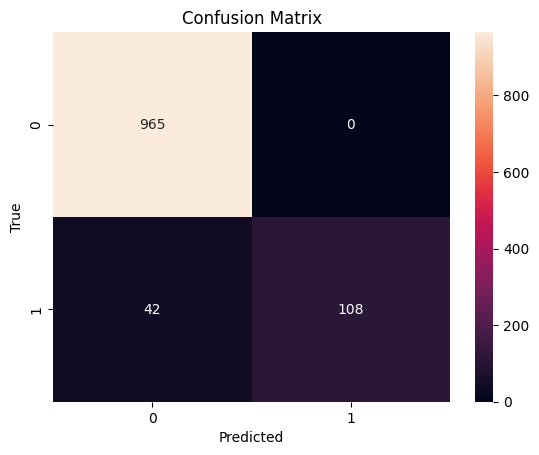

In [62]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm=confusion_matrix(Y_test,Y_pred)
sns.heatmap(cm,annot=True,fmt='d')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [63]:
from sklearn.metrics import classification_report
print(classification_report(Y_test,Y_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.72      0.84       150

    accuracy                           0.96      1115
   macro avg       0.98      0.86      0.91      1115
weighted avg       0.96      0.96      0.96      1115



In [73]:
sample=["Congratulations! You have won a free iphone click here now."]
sample_vector=vectorizer.transform(sample)
prediction=model.predict(sample_vector)
if prediction[0]==1:
    print("Spam Email")
else:
    print("Not Spam Email")

Not Spam Email
